In [2]:
!pip install -q imbalanced-learn


In [3]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, f1_score
)
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

RNG = np.random.default_rng(42)
N_SAMPLES = 50_000
FRAUD_RATE = 0.012
TRANSACTION_TYPES = ["PAYMENT", "TRANSFER", "CASH_OUT", "DEBIT", "CASH_IN"]
FRAUD_PRONE_TYPES = {"TRANSFER", "CASH_OUT"}
LABEL_COL = "isFraud"

In [4]:
# 2. Feature engineering

def engineer_features(df):
    df = df.copy()
    df["orig_balance_delta"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
    df["dest_balance_delta"] = df["newbalanceDest"] - df["oldbalanceDest"]
    df["amount_vs_orig_balance"] = df["amount"] / (df["oldbalanceOrg"] + 1)
    df["orig_emptied"] = (df["newbalanceOrig"] == 0).astype(int)
    df["dest_was_empty"] = (df["oldbalanceDest"] == 0).astype(int)
    df["errorBalanceOrig"] = df["newbalanceOrig"] + df["amount"] - df["oldbalanceOrg"]
    df["errorBalanceDest"] = df["oldbalanceDest"] + df["amount"] - df["newbalanceDest"]
    df["is_night"] = df["hour_of_day"].isin(range(0, 6)).astype(int)
    df = pd.get_dummies(df, columns=["type"], prefix="type")
    return df

df = engineer_features(data)
feature_cols = [c for c in df.columns if c not in (LABEL_COL, "step")]
X, y = df[feature_cols], df[LABEL_COL]
# 4. Train models

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=12, class_weight="balanced_subsample",
        random_state=42, n_jobs=-1
    ),
}

trained = {}
proba = {}

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    trained[name] = model
    proba[name] = model.predict_proba(X_test_scaled)[:, 1]
    print(f"Trained: {name}")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {len(X_train):,} | Fraud in train: {y_train.sum()}")
print(f"Test size:  {len(X_test):,} | Fraud in test:  {y_test.sum()}")

Train size: 37,500 | Fraud in train: 450
Test size:  12,500 | Fraud in test:  150


In [6]:
# 3. Balance training data with SMOTE (train set only)

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)
print(f"After SMOTE, train class balance: {np.bincount(y_train_bal)}")



After SMOTE, train class balance: [37050 37050]


In [7]:
# 4. Train models

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=12, class_weight="balanced_subsample",
        random_state=42, n_jobs=-1
    ),
}

trained = {}
proba = {}

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    trained[name] = model
    proba[name] = model.predict_proba(X_test_scaled)[:, 1]
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: Random Forest


In [8]:
# 5. Evaluate - classification reports

for name, model in trained.items():
    y_pred = model.predict(X_test_scaled)
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(classification_report(y_test, y_pred, target_names=["Legit", "Fraud"], digits=4))
    print(f"ROC-AUC: {roc_auc_score(y_test, proba[name]):.4f} | "
          f"PR-AUC: {average_precision_score(y_test, proba[name]):.4f} | "
          f"F1: {f1_score(y_test, y_pred):.4f}")


Logistic Regression
              precision    recall  f1-score   support

       Legit     1.0000    0.9997    0.9998     12350
       Fraud     0.9740    1.0000    0.9868       150

    accuracy                         0.9997     12500
   macro avg     0.9870    0.9998    0.9933     12500
weighted avg     0.9997    0.9997    0.9997     12500

ROC-AUC: 1.0000 | PR-AUC: 1.0000 | F1: 0.9868

Random Forest
              precision    recall  f1-score   support

       Legit     1.0000    1.0000    1.0000     12350
       Fraud     1.0000    1.0000    1.0000       150

    accuracy                         1.0000     12500
   macro avg     1.0000    1.0000    1.0000     12500
weighted avg     1.0000    1.0000    1.0000     12500

ROC-AUC: 1.0000 | PR-AUC: 1.0000 | F1: 1.0000


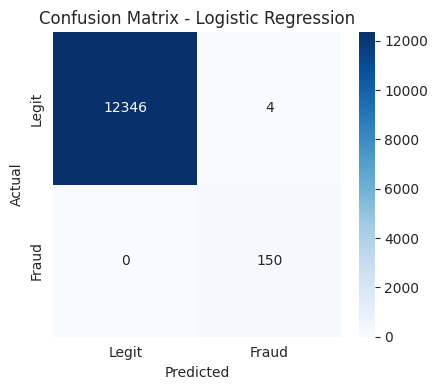

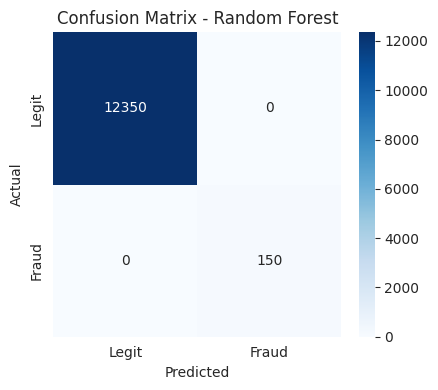

In [9]:
# 6. Confusion matrices (inline)

for name, model in trained.items():
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4.5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
    plt.title(f"Confusion Matrix - {name}")
    plt.ylabel("Actual"); plt.xlabel("Predicted")
    plt.tight_layout()
    plt.savefig(f"confusion_{name.replace(' ', '_')}.png", dpi=150)
    plt.show()

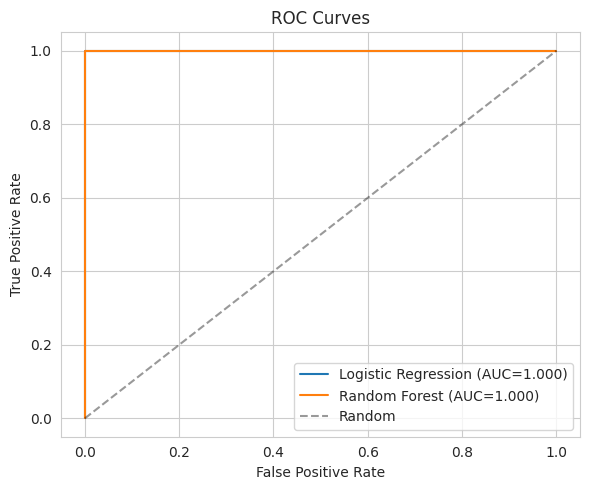

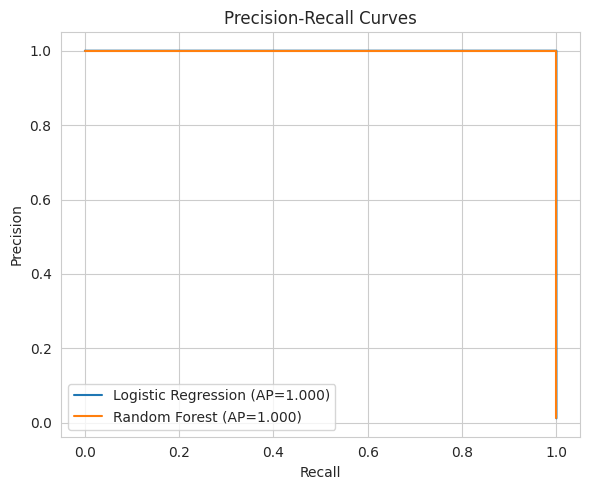

In [10]:
# 7. ROC and Precision-Recall curves (inline)

fig_roc, ax_roc = plt.subplots(figsize=(6, 5))
for name in trained:
    fpr, tpr, _ = roc_curve(y_test, proba[name])
    ax_roc.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba[name]):.3f})")
ax_roc.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
ax_roc.set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC Curves")
ax_roc.legend()
fig_roc.tight_layout()
fig_roc.savefig("roc_curves.png", dpi=150)
plt.show()

fig_pr, ax_pr = plt.subplots(figsize=(6, 5))
for name in trained:
    prec, rec, _ = precision_recall_curve(y_test, proba[name])
    ax_pr.plot(rec, prec, label=f"{name} (AP={average_precision_score(y_test, proba[name]):.3f})")
ax_pr.set(xlabel="Recall", ylabel="Precision", title="Precision-Recall Curves")
ax_pr.legend()
fig_pr.tight_layout()
fig_pr.savefig("pr_curves.png", dpi=150)
plt.show()

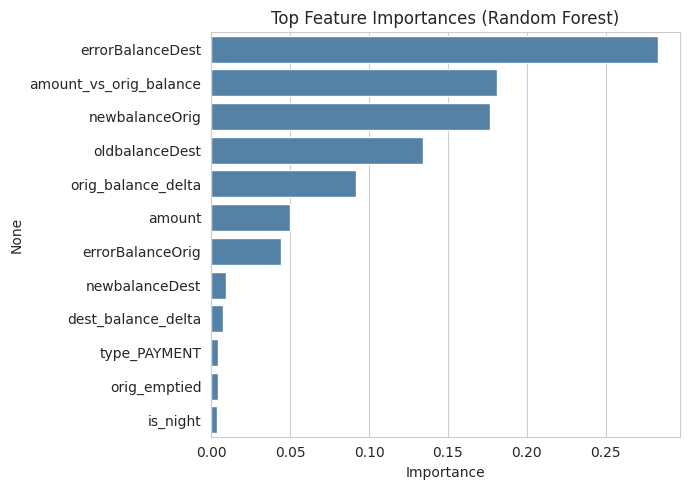

In [11]:
# 8. Feature importance (inline)

rf = trained["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False).head(12)
plt.figure(figsize=(7, 5))
sns.barplot(x=importances.values, y=importances.index, color="steelblue")
plt.title("Top Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

In [12]:
# 9. Optional: download the saved PNGs to your computer

from google.colab import files
for fname in ["confusion_Logistic_Regression.png", "confusion_Random_Forest.png",
              "roc_curves.png", "pr_curves.png", "feature_importance.png"]:
    files.download(fname)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>